# hibari 기초분석

### 1. mid 파일 전처리

* hibari의 최소 시간단위를 고려하여 8분음표를 기준으로 정제합니다.

In [1]:
from util import adjust_to_eighth_note

file_name = "Ryuichi_Sakamoto_-_hibari.mid"
adjusted_notes = adjust_to_eighth_note(file_name)

adn_1 = adjusted_notes[:2006]
adn_2 = adjusted_notes[2006:]

adn_1_real = adn_1[:-59]
adn_2_real = adn_2[59:]

adjusted_notes_real = adn_1_real + adn_2_real

# len(adn_1_real) / 59 , len(adn_2_real) / 59

1th instrument ending : index 2006
2th instrument ending : index 3953


c:\Users\82104\Developments\.venv\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


In [2]:
from util import notes_analyzer

notes, pitch_to_note, __ = notes_analyzer(adjusted_notes_real)
notes

,Pitch,count,Note Name,Frequency
0,72,390,C5,523.251131
1,64,325,E4,329.627557
2,74,325,D5,587.329536
3,67,325,G4,391.995436
4,69,325,A4,440.000000
5,65,260,F4,349.228231
6,59,260,B3,246.941651
7,76,260,E5,659.255114
8,57,195,A3,220.000000
9,60,195,C4,261.625565


### 3. Try Approach for monotonic music
* 가설 : module 자체에 내제된 빈도수만큼으로 환원될 것이다.
* bipartiton(inst 1과 2사이에만) 가중치를 줍니다.

In [3]:
from util import label_active_chord_by_onset

adn_1_chord = label_active_chord_by_onset(adn_1_real)
adn_2_chord = label_active_chord_by_onset(adn_2_real)

In [4]:
adn_1_real

[(0, 67, 1),
 (0, 52, 2),
 (0, 59, 2),
 (0, 62, 2),
 (1, 72, 2),
 (2, 69, 3),
 (2, 74, 3),
 (2, 53, 4),
 (2, 60, 4),
 (3, 81, 4),
 (4, 71, 5),
 (4, 79, 5),
 (4, 55, 6),
 (4, 64, 6),
 (5, 76, 6),
 (6, 67, 7),
 (6, 72, 7),
 (6, 57, 8),
 (6, 64, 8),
 (7, 74, 8),
 (8, 69, 9),
 (8, 76, 9),
 (8, 59, 10),
 (8, 65, 10),
 (9, 72, 10),
 (10, 74, 11),
 (10, 60, 16),
 (10, 65, 16),
 (11, 69, 16),
 (16, 67, 17),
 (16, 52, 18),
 (16, 59, 18),
 (16, 62, 18),
 (17, 72, 18),
 (18, 69, 19),
 (18, 74, 19),
 (18, 53, 20),
 (18, 60, 20),
 (19, 81, 20),
 (20, 71, 21),
 (20, 79, 21),
 (20, 55, 22),
 (20, 64, 22),
 (21, 76, 22),
 (22, 67, 23),
 (22, 72, 23),
 (22, 57, 24),
 (22, 64, 24),
 (23, 76, 24),
 (24, 69, 25),
 (24, 74, 25),
 (24, 59, 26),
 (24, 65, 26),
 (25, 71, 26),
 (26, 67, 27),
 (26, 72, 27),
 (26, 57, 32),
 (26, 64, 32),
 (27, 65, 32),
 (32, 67, 33),
 (32, 52, 34),
 (32, 59, 34),
 (32, 62, 34),
 (33, 72, 34),
 (34, 69, 35),
 (34, 74, 35),
 (34, 53, 36),
 (34, 60, 36),
 (35, 81, 36),
 (36, 71, 37

In [5]:
adn_1_chord[16:32]

[0, 1, 2, 3, 4, 5, 6, 12, 13, 14, 15, 16, 16, 16, 16, 16]

* 두 list에서 인덱스를 일치시켜 비교할 수 있는 범위(5마디 2박자 ~ 132마디)만 자릅니다.

In [6]:
# (length of adn_i_chord) = (# module repeated) * (length of each period)
# adn_1_chord : 1056 = 33 * 32
# adn_2_chord : (1 + 1055) = 32 * 33 
# 임을 고려할 때

# len = 1023
adn_1_chord_ = adn_1_chord[33:] 
adn_2_chord_ = adn_2_chord[:-32]

### WK6 Draft

In [7]:
chord_1_132 = adn_1_chord.copy()
chord_2_132 = [None, *adn_2_chord]
# each of which is of length 1056 (132 bars)

# chord_1_132는 규칙적으로 반복되므로 굳이 solo 파트를 뒤로 붙이지 않아도
# chord_2_132와 원형적 alignness를 보고자 할 때 가능하다.

adn_1_chord_ = chord_1_132[:-32]
adn_2_chord_ = chord_2_132[:-32]

In [8]:
# print(adn_1_chord_[0:16])
# print(adn_2_chord_[0:16])
# print(adn_1_chord_[16:32])
# print(adn_2_chord_[16:32])

In [9]:
# print(adn_1_chord_[32:48])
# print(adn_2_chord_[32:48])
# print(adn_1_chord_[48:64])
# print(adn_2_chord_[48:64])

* 가중치 계산 결과를 확인해보면 대칭에 '가까운' 결과가 나옵니다.

In [10]:
# import util
# import importlib
# importlib.reload(util)
from util import get_chords_inter_connected
import pandas as pd

lag = 1
weight_mtrx = get_chords_inter_connected(adn_1_chord_, adn_2_chord_, lag)
weight_mtrx

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,8,4,8,8,8,8,8,4,4,4,4,20,4,4,4,4,20
1,8,8,4,8,8,8,8,4,4,4,4,20,4,4,4,4,20
2,8,8,8,4,8,8,8,4,4,4,4,20,4,4,4,4,20
3,8,8,8,8,4,8,8,4,4,4,4,20,4,4,4,4,20
4,8,8,8,8,8,4,8,4,4,4,4,20,4,4,4,4,20
5,8,8,8,8,8,8,4,4,4,4,4,20,4,4,4,4,20
6,8,8,8,8,8,8,8,2,4,4,4,20,2,4,4,4,20
7,4,4,4,4,4,4,4,2,0,2,2,10,2,2,2,2,10
8,4,4,4,4,4,4,4,2,2,0,2,10,2,2,2,2,10
9,4,4,4,4,4,4,4,2,2,2,0,10,2,2,2,2,10


In [11]:
from util import get_UTMconnected

weight_UTM = get_UTMconnected(weight_mtrx)
weight_UTM

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,8,12,16,16,16,16,16,8,8,8,8,38,8,8,8,8,37
1,0,8,12,16,16,16,16,8,8,8,8,40,8,8,8,8,38
2,0,0,8,12,16,16,16,8,8,8,8,40,8,8,8,8,38
3,0,0,0,8,12,16,16,8,8,8,8,40,8,8,8,8,38
4,0,0,0,0,8,12,16,8,8,8,8,40,8,8,8,8,38
5,0,0,0,0,0,8,12,8,8,8,8,40,8,8,8,8,38
6,0,0,0,0,0,0,8,6,8,8,8,40,6,8,8,8,38
7,0,0,0,0,0,0,0,2,2,4,4,20,4,4,4,4,19
8,0,0,0,0,0,0,0,0,2,2,4,20,4,4,4,4,19
9,0,0,0,0,0,0,0,0,0,2,2,20,4,4,4,4,19


In [12]:
module_chord_label = pd.DataFrame(adn_1_chord[:32])
module_chord_label.value_counts().to_frame()

,count
0,
16,5
11,5
5,2
1,2
6,2
0,2
4,2
3,2
2,2


* 모듈 1개에서 각 화음의 등장빈도(혹은 지속길이)를 확인하면 위의 결과와 합치함을 알 수 있습니다.

In [13]:
from util import (group_pitches_with_duration_, notes_label_n_counts, 
                  chord_label_to_note_labels, transform_dict, chord_label_dict)

module_notes = adn_1_real[:59]
active_module = group_pitches_with_duration_(module_notes)

notes_label, notes_counts = notes_label_n_counts(module_notes)
chord_label = chord_label_dict(active_module)

# notes = (pitch, duration)
notes_dict = chord_label_to_note_labels(chord_label, notes_label)
pitches_dict = transform_dict(chord_label)
pitch_classes_dict = transform_dict(chord_label, project=True)


In [14]:
# print("chord_to_notes_dict")
# for chord, note in chord_to_notes_dict.items():
#     print(f"{chord}: {note}")

# print("pitches_dict")
# for chord, pitch in pitches_dict.items():
#     print(f"{chord}: {pitch}")

# print("pitch_classes_dict")
# for chord, pitch_class in pitch_classes_dict.items():
#     print(f"{chord}: {pitch_class}")

In [15]:
# import util
# import importlib
# importlib.reload(util)
from util import refine_connectedness

notes_mtrx = refine_connectedness(weight_UTM, notes_dict)
pitches_mtrx = refine_connectedness(weight_UTM, pitches_dict)
pitches_cls_mtrx = refine_connectedness(weight_UTM, pitch_classes_dict)


In [16]:
print(weight_mtrx.sum().sum())
print(notes_mtrx.sum().sum())
print(pitches_mtrx.sum().sum())
print(pitches_cls_mtrx.sum().sum()) 


# 1번째 값은 변하지 않았다. 더하는 위치는 달라졌어도 더해주는 횟수는 모두 같은 듯 
# 이제 2, 3번째가 같지 않고, 2~4번째가 모두 거의 비슷해졌다. 왜 그러지?
# 12620 / 1952 = 6.465 로부터 뭔가를 알 수 있나?

# 마지막 dict : projection을 하되 박자는 다르게 하는.

1953
12630.0
12812.0
12349.0


In [17]:
# import util
# import importlib
# importlib.reload(util)
from util import get_chords_intra_connected

# 함수 실행 및 결과 출력
weight_mtrx_1 = get_chords_intra_connected(adn_1_chord_)
weight_mtrx_1

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0,64,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,64,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,64,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,64,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,64,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,64,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,32,0,0,0,0,32,0,0,0,0
7,0,0,0,0,0,0,0,0,32,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,32,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,32,0,0,0,0,0,0


In [18]:
weight_mtrx_2 = get_chords_intra_connected(adn_2_chord_, lag=1)
weight_mtrx_2

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0,62,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,62,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,62,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,62,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,62,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,62,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,31,0,0,0,0,31,0,0,0,0
7,0,0,0,0,0,0,0,0,31,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,31,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,31,0,0,0,0,0,0


### pseudo-Pipeline
* approach 1 : inter / intra distance를 모두 구하고 서로 구하는 방법
* np.inf가 더 많아진다.

In [19]:
from util import is_distance_matrix_from

weight_mtrx = get_chords_inter_connected(adn_1_chord_, adn_2_chord_, lag=1)
inter_distance = is_distance_matrix_from(weight_mtrx, pitches_dict)

weight_mtrx_1 = get_chords_intra_connected(adn_1_chord_, lag=1)
intra_distance_1 = is_distance_matrix_from(weight_mtrx_1, pitches_dict)

weight_mtrx_2 = get_chords_intra_connected(adn_2_chord_, lag=1)
intra_distance_2 = is_distance_matrix_from(weight_mtrx_2, pitches_dict)

# UTM에서 inter에서 없었던 inf가 너무 많아진다.
timeflow_distance_ = inter_distance + intra_distance_1 + intra_distance_2
timeflow_distance_

,52,53,55,57,59,60,62,64,65,67,69,71,72,74,76,79,81
52,0.067468,0.048421,inf,inf,0.042624,0.027663,0.067468,inf,0.052423,inf,0.028416,inf,0.043659,0.044912,inf,inf,inf
53,0.048421,0.067468,0.048421,inf,inf,0.039819,inf,0.036384,inf,inf,inf,0.054481,inf,inf,inf,0.067468,0.081754
55,inf,0.048421,0.067468,0.038333,inf,inf,inf,0.021433,inf,0.054481,inf,inf,0.048421,inf,0.050985,inf,inf
57,inf,inf,0.038333,0.026851,0.050985,inf,inf,0.026851,0.025106,inf,0.043659,inf,inf,0.061166,0.077209,inf,inf
59,0.042624,inf,inf,0.050985,0.024210,0.020877,0.067468,0.051286,0.016965,0.077794,0.026433,0.080175,0.025681,0.032039,inf,inf,inf
60,0.027663,0.039819,inf,inf,0.020877,0.026546,inf,0.034400,0.065682,inf,0.068410,0.046460,inf,inf,inf,0.067468,0.081754
62,0.067468,inf,inf,inf,0.067468,inf,0.067468,inf,0.052423,inf,0.028416,inf,0.043659,0.044912,inf,inf,inf
64,inf,0.036384,0.021433,0.026851,0.051286,0.034400,inf,0.011882,0.023210,0.046040,0.036856,inf,0.041958,0.043949,0.029391,inf,inf
65,0.052423,inf,inf,0.025106,0.016965,0.065682,0.052423,0.023210,0.018310,0.089824,0.070861,0.091286,0.055564,0.087318,inf,inf,inf
67,inf,inf,0.054481,inf,0.077794,inf,inf,0.046040,0.089824,inf,0.071445,inf,0.046040,0.079637,0.085247,inf,inf


* approach 2 : inter / intra weight를 모두 더한 이후 distance를 구하는 방법

In [20]:
timeflow_weight = weight_mtrx + weight_mtrx_1 + weight_mtrx_2
timeflow_distance = is_distance_matrix_from(timeflow_weight, pitches_dict)
timeflow_distance

,52,53,55,57,59,60,62,64,65,67,69,71,72,74,76,79,81
52,0.006494,0.005376,0.015625,0.005376,0.004587,0.002915,0.006494,0.004000,0.003058,0.017857,0.003058,0.020833,0.004762,0.004950,0.015625,0.031250,0.031250
53,0.005376,0.006494,0.005376,0.006410,0.015625,0.004000,inf,0.002924,0.004237,0.020833,0.008333,0.005882,0.015625,0.017857,0.015625,0.006494,0.006849
55,0.015625,0.005376,0.006494,0.003597,0.015625,0.010417,inf,0.002315,0.004237,0.005882,0.008929,0.041667,0.005376,0.020833,0.005618,0.125000,inf
57,0.005376,0.006410,0.003597,0.002740,0.005618,0.013889,inf,0.002740,0.002257,0.038462,0.004762,0.062500,0.026316,0.006250,0.006757,inf,inf
59,0.004587,0.015625,0.015625,0.005618,0.002688,0.002212,0.006494,0.002433,0.001502,0.007519,0.002639,0.008130,0.002825,0.003559,0.013514,0.031250,0.031250
60,0.002915,0.004000,0.010417,0.013889,0.002212,0.002667,inf,0.001984,0.001912,0.013889,0.003745,0.005155,0.011364,0.012195,0.011364,0.006494,0.006849
62,0.006494,inf,inf,inf,0.006494,inf,0.006494,0.004000,0.003058,0.017857,0.003058,0.020833,0.004762,0.004950,0.015625,0.031250,0.031250
64,0.004000,0.002924,0.002315,0.002740,0.002433,0.001984,0.004000,0.001255,0.001473,0.005102,0.003106,0.025000,0.004464,0.004808,0.003067,0.125000,inf
65,0.003058,0.004237,0.004237,0.002257,0.001502,0.001912,0.003058,0.001473,0.001508,0.009901,0.005025,0.010101,0.005952,0.009524,0.029412,inf,inf
67,0.017857,0.020833,0.005882,0.038462,0.007519,0.013889,0.017857,0.005102,0.009901,0.020000,0.005291,0.031250,0.005102,0.008000,0.009174,0.062500,0.062500


In [21]:
weight_simul = get_chords_inter_connected(adn_1_chord_, adn_2_chord_, lag=0)
simul_distance = is_distance_matrix_from(weight_simul, pitches_dict)
simul_distance

,52,53,55,57,59,60,62,64,65,67,69,71,72,74,76,79,81
52,0.041667,0.015625,0.015625,0.006250,0.011364,0.006250,0.041667,0.004464,0.004167,0.019231,0.006944,0.020833,0.011905,0.012500,0.015625,0.03125,0.03125
53,0.015625,0.041667,0.015625,0.006250,0.015625,0.008333,inf,0.004464,0.004167,0.020833,0.008621,0.020833,0.015625,0.019231,0.015625,0.03125,0.05000
55,0.015625,0.015625,0.041667,0.006250,0.015625,0.010417,inf,0.005435,0.004167,0.020833,0.008929,0.050000,0.015625,0.020833,0.019231,0.25000,inf
57,0.006250,0.006250,0.006250,0.005556,0.017857,0.013889,inf,0.005556,0.003731,0.050000,0.011364,0.062500,0.031250,0.027778,0.041667,inf,inf
59,0.011364,0.015625,0.015625,0.017857,0.008929,0.004808,0.041667,0.003049,0.002551,0.014706,0.005208,0.016667,0.009615,0.010417,0.013889,0.03125,0.03125
60,0.006250,0.008333,0.010417,0.013889,0.004808,0.005556,inf,0.002551,0.002137,0.013889,0.005000,0.013889,0.011364,0.013158,0.011364,0.03125,0.05000
62,0.041667,inf,inf,inf,0.041667,inf,0.041667,0.004464,0.004167,0.019231,0.006944,0.020833,0.011905,0.012500,0.015625,0.03125,0.03125
64,0.004464,0.004464,0.005435,0.005556,0.003049,0.002551,0.004464,0.002747,0.001969,0.014706,0.005000,0.027778,0.010417,0.011905,0.013158,0.25000,inf
65,0.004167,0.004167,0.004167,0.003731,0.002551,0.002137,0.004167,0.001969,0.002381,0.025000,0.007576,0.027778,0.022727,0.025000,0.031250,inf,inf
67,0.019231,0.020833,0.020833,0.050000,0.014706,0.013889,0.019231,0.014706,0.025000,0.025000,0.007812,0.031250,0.014706,0.015625,0.020833,0.06250,0.06250


In [22]:
import gudhi
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx


def get_cycle_from_distance(distance_df : pd.DataFrame, barcode = False, PD = False, BDC = False) : 

    distance_matrix = distance_df.copy()

    # Vietoris-Rips 복합체 생성
    rips_complex = gudhi.RipsComplex(distance_matrix=distance_matrix.values, max_edge_length=1)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=2) # 최대 차원 설정 (1차원 homology를 보려면 최소 2로 설정)

    # Persistent Homology 계산
    persistence = simplex_tree.persistence()

    # 결과 출력 (Pairing)
    # print(persistence)

    if barcode : # Barcode 그리기
        gudhi.plot_persistence_barcode(persistence)
        plt.title("Barcode")
        plt.xlabel("Birth-Death Time")
        plt.ylabel("Homology Dimension")
        plt.show()

    if PD : # Persistence Diagram 그리기
        gudhi.plot_persistence_diagram(persistence)
        plt.title("Persistence Diagram")
        plt.xlabel("Birth Time")
        plt.ylabel("Death Time")
        plt.show()


    cycle_count = 0 # cycle 개수를 저장할 변수 초기화
    lifespans = []
    cycle_vertices = [] # cycle을 이루는 vertex를 저장할 리스트 추가


    # 1차원 homology (cycle) 확인
    for dim, (birth, death) in persistence: # simplex_tree.persistence_intervals() 대신 persistence 사용
        if dim == 1:
            # Check if the simplex exists in the simplex tree
            simplex_exists = simplex_tree.find([birth])
            
            if simplex_exists:
                # Extract vertices from the cycle
                vertices = set() # cycle vertex를 얻는 로직이 필요합니다.

                # simplex_tree에 있는 모든 simplex를 순회하며 birth time과 같은 simplex를 찾습니다.
                for simplex, fil_val in simplex_tree.get_skeleton(1): # 1차원 simplex만 확인
                    if fil_val == birth: # filtration value가 birth와 같은 simplex
                        for vertex in simplex: # simplex를 구성하는 vertex들을 set에 추가
                            vertices.add(vertex)

                cycle_vertices.append(vertices)
            
            life = death - birth
            lifespans.append(life)
            cycle_count += 1 # cycle 개수 증가
            if BDC :
                print(f"1차원 Cycle: Birth = {birth}, Death = {death}, Lifespan = {life}")

    mean = np.mean(lifespans)
    std_dev = np.std(lifespans)
    longest = max(lifespans)

    return cycle_count, mean, std_dev, longest, cycle_vertices

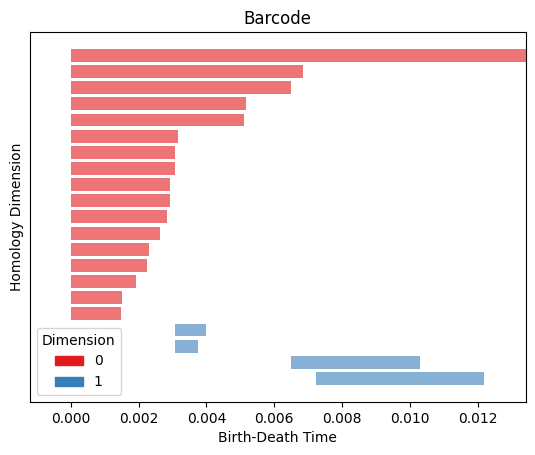

1차원 Cycle: Birth = 0.007246376811594203, Death = 0.012195121951219513, Lifespan = 0.00494874513962531
1차원 Cycle: Birth = 0.006493506493506494, Death = 0.010309278350515464, Lifespan = 0.00381577185700897
1차원 Cycle: Birth = 0.0030581039755351682, Death = 0.004, Lifespan = 0.0009418960244648319
1차원 Cycle: Birth = 0.0030581039755351682, Death = 0.003745318352059925, Lifespan = 0.0006872143765247569
[{16, 10, 13}, {0, 1, 4, 5, 6, 11, 14, 15}, {0, 8, 10, 6}, {0, 8, 10, 6}]
[{0, 1, 4, 5, 6, 11, 14, 15}, {16, 10, 13}, {0, 8, 10, 6}]


In [25]:
cycle_count, mean, std_dev, longest, cycle_vertices = get_cycle_from_distance(timeflow_distance,
                                                                              barcode=True, BDC = True)

temp = set(frozenset(s) for s in cycle_vertices)
unique_cycle_vertices = [set(s) for s in temp]

print(cycle_vertices)
print(unique_cycle_vertices)

# 왜 차이가 나는지 모르겠다.. 
# {0, 8, 10, 6} 얘는 뭐지... 

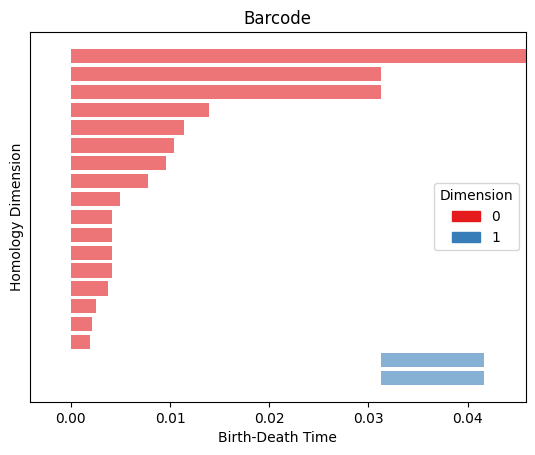

1차원 Cycle: Birth = 0.03125, Death = 0.041666666666666664, Lifespan = 0.010416666666666664
1차원 Cycle: Birth = 0.03125, Death = 0.041666666666666664, Lifespan = 0.010416666666666664
[{0, 1, 3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16}, {0, 1, 3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16}]
[{0, 1, 3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16}]


In [26]:
cycle_count, mean, std_dev, longest, cycle_vertices = get_cycle_from_distance(simul_distance,
                                                                              barcode=True, BDC = True)

temp = set(frozenset(s) for s in cycle_vertices)
unique_cycle_vertices = [set(s) for s in temp]

print(cycle_vertices)
print(unique_cycle_vertices)

In [27]:
weight_mtrx_1 = get_chords_intra_connected(adn_1_chord_, lag=1)
weight_mtrx_2 = get_chords_intra_connected(adn_2_chord_, lag=1)
weight_mtrx = get_chords_inter_connected(adn_1_chord_, adn_2_chord_, lag=1)

intra_weights = weight_mtrx_1 + weight_mtrx_2
inter_weight = weight_mtrx

notes_dict['name'] = 'notes_dict'
pitches_dict['name'] = 'pitches_dict'
pitch_classes_dict['name'] = 'pitch_classes_dict'

on rate 0.0...


c:\Users\82104\Developments\.venv\lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


on rate 0.01...


c:\Users\82104\Developments\.venv\lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


on rate 0.02...


c:\Users\82104\Developments\.venv\lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


on rate 0.03...
on rate 0.04...
on rate 0.05...
on rate 0.06...
on rate 0.07...
on rate 0.08...
on rate 0.09...
on rate 0.1...
on rate 0.11...
on rate 0.12...
on rate 0.13...
on rate 0.14...
on rate 0.15...
on rate 0.16...
on rate 0.17...
on rate 0.18...
on rate 0.19...
on rate 0.2...
on rate 0.21...
on rate 0.22...
on rate 0.23...
on rate 0.24...
on rate 0.25...
on rate 0.26...
on rate 0.27...
on rate 0.28...
on rate 0.29...
on rate 0.3...
on rate 0.31...
on rate 0.32...
on rate 0.33...
on rate 0.34...
on rate 0.35...
on rate 0.36...
on rate 0.37...
on rate 0.38...
on rate 0.39...
on rate 0.4...
on rate 0.41...
on rate 0.42...
on rate 0.43...
on rate 0.44...
on rate 0.45...
on rate 0.46...
on rate 0.47...
on rate 0.48...
on rate 0.49...
on rate 0.5...
on rate 0.51...
on rate 0.52...
on rate 0.53...
on rate 0.54...
on rate 0.55...
on rate 0.56...
on rate 0.57...
on rate 0.58...
on rate 0.59...
on rate 0.6...
on rate 0.61...
on rate 0.62...
on rate 0.63...
on rate 0.64...
on rate 0.65..

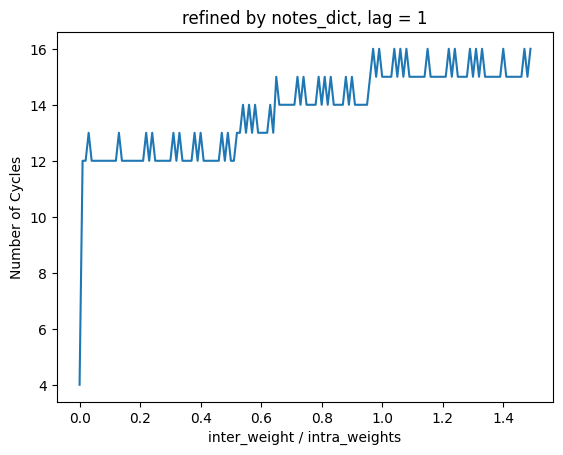

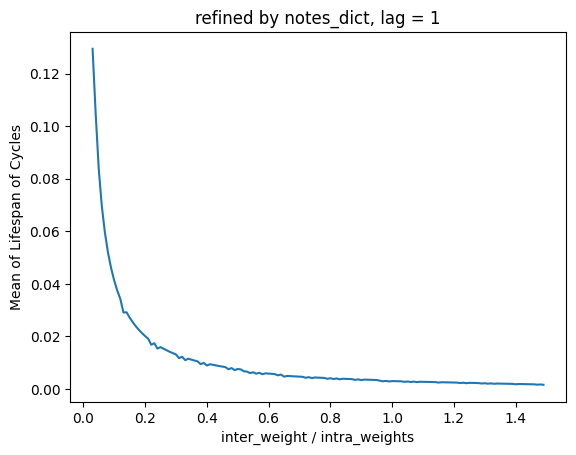

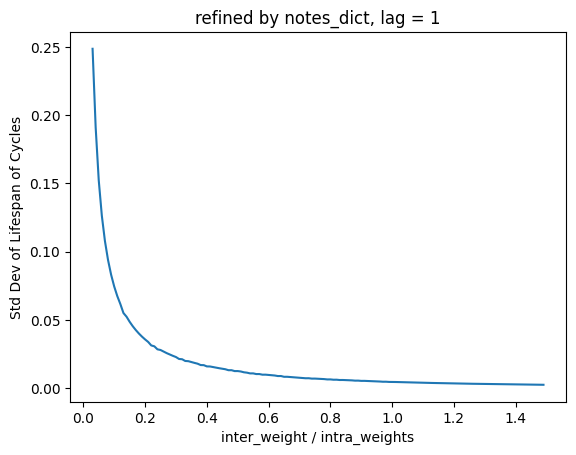

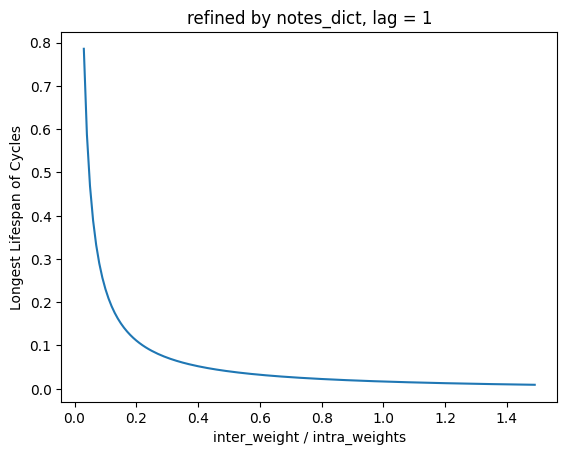

In [30]:
def search_optimal_rate_n_dict(intra_weights, inter_lag = int, refine_dict : dict = notes_dict,
                                rate_start = 0.03, rate_end = 1.5, step = 0.01) :
    
    # rate_start = 0.01, 0.02는 사소한 에러가 생겨서 스킵.
    inter_weight = get_chords_inter_connected(adn_1_chord_, adn_2_chord_, lag=inter_lag)
    
    start = round(rate_start / step)
    end = round(rate_end / step)
    cycles_profile = []
    cycles_vertices = []

    for a in range(start, end, 1) :
        rate = round(a * step, 4)
        print(f"on rate {rate}...")

        timeflow_weight = intra_weights + rate * inter_weight 
        timeflow_distance = is_distance_matrix_from(timeflow_weight, refine_dict)

        cycle_count, mean, std_dev, longest, cycle_vertices = get_cycle_from_distance(timeflow_distance)

        result_1 = (rate, cycle_count, mean, std_dev, longest)
        cycles_profile.append(result_1)

        result_2 = (rate, cycle_vertices)
        cycles_vertices.append(result_2)

    x = [point[0] for point in cycles_profile]
    y1 = [point[1] for point in cycles_profile]
    y2 = [point[2] for point in cycles_profile]
    y3 = [point[3] for point in cycles_profile]
    y4 = [point[4] for point in cycles_profile]

    # Y1 plot
    plt.figure()  # 새로운 Figure 생성
    plt.plot(x, y1)
    plt.title(f"refined by {refine_dict['name']}, lag = {inter_lag}")
    plt.xlabel("inter_weight / intra_weights")
    plt.ylabel("Number of Cycles")
    plt.show()

    # Y2 plot
    plt.figure()  # 새로운 Figure 생성
    plt.plot(x, y2)
    plt.title(f"refined by {refine_dict['name']}, lag = {inter_lag}")
    plt.xlabel("inter_weight / intra_weights")
    plt.ylabel("Mean of Lifespan of Cycles")
    plt.show()

    # Y3 plot
    plt.figure()  # 새로운 Figure 생성
    plt.plot(x, y3)
    plt.title(f"refined by {refine_dict['name']}, lag = {inter_lag}")
    plt.xlabel("inter_weight / intra_weights")
    plt.ylabel("Std Dev of Lifespan of Cycles")
    plt.show()

    # Y4 plot
    plt.figure()  # 새로운 Figure 생성
    plt.plot(x, y4)
    plt.title(f"refined by {refine_dict['name']}, lag = {inter_lag}")
    plt.xlabel("inter_weight / intra_weights")
    plt.ylabel("Longest Lifespan of Cycles")
    plt.show()

    return cycles_profile, cycles_vertices

cycles_profile_n1, cycles_vertices_n1 = search_optimal_rate_n_dict(intra_weights, inter_lag = 1, 
                                                        rate_start = 0.00, refine_dict = notes_dict)

In [32]:
def get_rate_range_of(data):
  """
  입력 데이터 (rate, vertices set list) 로부터 vertices set별 rate 범위를 계산하여 딕셔너리를 반환합니다.

  Args:
    data: (float, list of set) 형태의 튜플 리스트

  Returns:
    {vertices set: [min_rate, max_rate]} 형태의 딕셔너리
  """
  result_dict = {}

  for rate, vertices_sets in data:
    for vertex_set in vertices_sets:
      if len(vertex_set) > 1 :
        # frozenset으로 변환하여 딕셔너리의 키로 사용 (set은 mutable이므로 키로 사용 불가)
        frozen_set = frozenset(vertex_set)

        if frozen_set in result_dict:
          # 기존에 있던 vertices set인 경우, rate 범위 업데이트
          result_dict[frozen_set][0] = min(result_dict[frozen_set][0], rate)
          result_dict[frozen_set][1] = max(result_dict[frozen_set][1], rate)
        else:
          # 새로운 vertices set인 경우, rate 범위 초기화
          result_dict[frozen_set] = [rate, rate]

  return result_dict

# 데이터 처리
result_dictionary = get_rate_range_of(cycles_vertices_n1)

# 결과 출력
for key, value in result_dictionary.items():
  print(f"Vertices Set: {set(key)}, Rate Range: {value}")


Vertices Set: {0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 13, 14, 15, 17, 18, 19, 20, 21, 22}, Rate Range: [0.0, 0.0]
Vertices Set: {19, 22, 15}, Rate Range: [0.01, 1.49]
Vertices Set: {0, 1, 2, 3, 5, 6, 8, 15, 18}, Rate Range: [0.01, 1.48]
Vertices Set: {9, 10}, Rate Range: [0.01, 1.43]
Vertices Set: {0, 1, 3, 5, 6, 8, 9, 17, 20, 21}, Rate Range: [0.01, 1.48]
Vertices Set: {0, 11, 5}, Rate Range: [0.01, 1.25]
Vertices Set: {9, 15}, Rate Range: [0.01, 1.49]
Vertices Set: {0, 16, 8, 14}, Rate Range: [0.01, 1.01]
Vertices Set: {2, 3, 20, 5, 11}, Rate Range: [0.01, 1.43]
Vertices Set: {1, 2, 17, 6, 14}, Rate Range: [0.01, 1.49]
Vertices Set: {0, 1, 5, 6, 8, 17, 20, 21}, Rate Range: [0.02, 1.45]
Vertices Set: {11, 5}, Rate Range: [0.02, 1.49]
Vertices Set: {11, 3, 5}, Rate Range: [0.02, 1.49]
Vertices Set: {0, 1, 2, 5, 6}, Rate Range: [0.03, 1.49]
Vertices Set: {0, 1, 17, 20, 5, 6, 8}, Rate Range: [0.03, 1.49]
Vertices Set: {0, 2, 3, 18, 8, 15}, Rate Range: [0.03, 1.49]
Vertices Set: {1, 3, 21, 6, 9},